# 05 Site explorer and the reactive sign convention

Two jobs:

1. **Unpack individual sites** — daily operational plots in the style of
   `ausgrid_analysis/notebooks/02c_explore_voltvar_voltwatt`, plus per-site Volt-VAr
   curves against the AS/NZS 4777.2 requirement.
2. **Settle the reactive sign**, fleet-wide, with every step showing whether the number
   on screen is the **raw delivered** value or the **flipped stored** one.

## Sign provenance — read this before any plot

Two orientations exist, and every function here carries both:

| column | meaning |
|---|---|
| `Q_raw_var` | straight from the delivered Parquet, **nothing applied** |
| `Q_raw_kvar` | `Q_raw_var / 1000` — sign still untouched |
| `Q_stored_kvar` | what `se_interval` holds, and what D9/D10 scored: `-1 × raw / 1000` |

Active power is **not** transformed. `ACTIVE_POWER_SIGN = +1`, SolarEdge reports a
production magnitude, and there are no negative values anywhere in the delivery.

Every figure stamps its orientation in the title. If it says `STORED`, the flip is
applied. If it says `RAW`, it is as SolarEdge delivered it.

In [242]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

_current = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in (_current, *_current.parents)
     if (p / "solar_edge").is_dir() and (p / "bms_sa_review").is_dir()),
    None,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from solar_edge.config import se_config as C
from solar_edge.lib import se_store, se_explore as ex, se_sign as sign
from solar_edge.lib import se_params
from solar_edge.lib import se_counterfactual as ctf

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

con = se_store.connect()
config = se_params.CONFIG    # same cohort/params as notebooks 02-03
print(f"REACTIVE_POWER_SIGN = {C.REACTIVE_POWER_SIGN:+.0f}   "
      f"(stored Q = {C.REACTIVE_POWER_SIGN:+.0f} x raw / 1000)")
print(f"ACTIVE_POWER_SIGN   = {C.ACTIVE_POWER_SIGN:+.0f}   (no change)")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
REACTIVE_POWER_SIGN = +1   (stored Q = +1 x raw / 1000)
ACTIVE_POWER_SIGN   = +1   (no change)


## 1. Verify the transform against the raw files

Before arguing about which orientation is correct, confirm what the store actually did.

This re-reads the delivered Parquet for one site, re-applies the timezone conversion
independently, joins on the UTC instant, and checks that
`Q_stored_kvar == -1 × Q_raw_var / 1000` on every row. It also checks active power was
left alone.

If `n_Q_mismatched` is anything but 0, stop — the store is not what the rest of this
notebook assumes.

In [243]:
SITE = "AUS034"        
# SITE = "AUS351"
display(ex.verify_sign_transform(con, SITE).T)
display(ex.site_profile(con, SITE))

,0
n_compared,53739
expected_Q_rule,+1 x raw / 1000
n_Q_mismatched,0.0
max_Q_abs_diff,0.0
expected_P_rule,+1 x raw / 1000
n_P_mismatched,0.0


site_alias                               AUS034
state                           New South Wales
postcode                                   2290
n_phases                                      1
is_three_phase                            False
n_intervals                               53737
n_days_observed                             365
has_night_generation_anomaly              False
s_99                                       9.69
p_99                                       9.68
pct_derating                             34.725
med_Q_stored_above_250                   0.2597
med_Q_stored_deadband                    0.1914
Name: 0, dtype: object

## 2. The per-site curve — which orientation matches the standard?

Median Q against voltage for one site, drawn **both ways**, with the required curve and
its ±4% tolerance band in magenta.

The question the plot asks: *which trace sits on the same side of zero as the
requirement, and inside its tolerance band?*

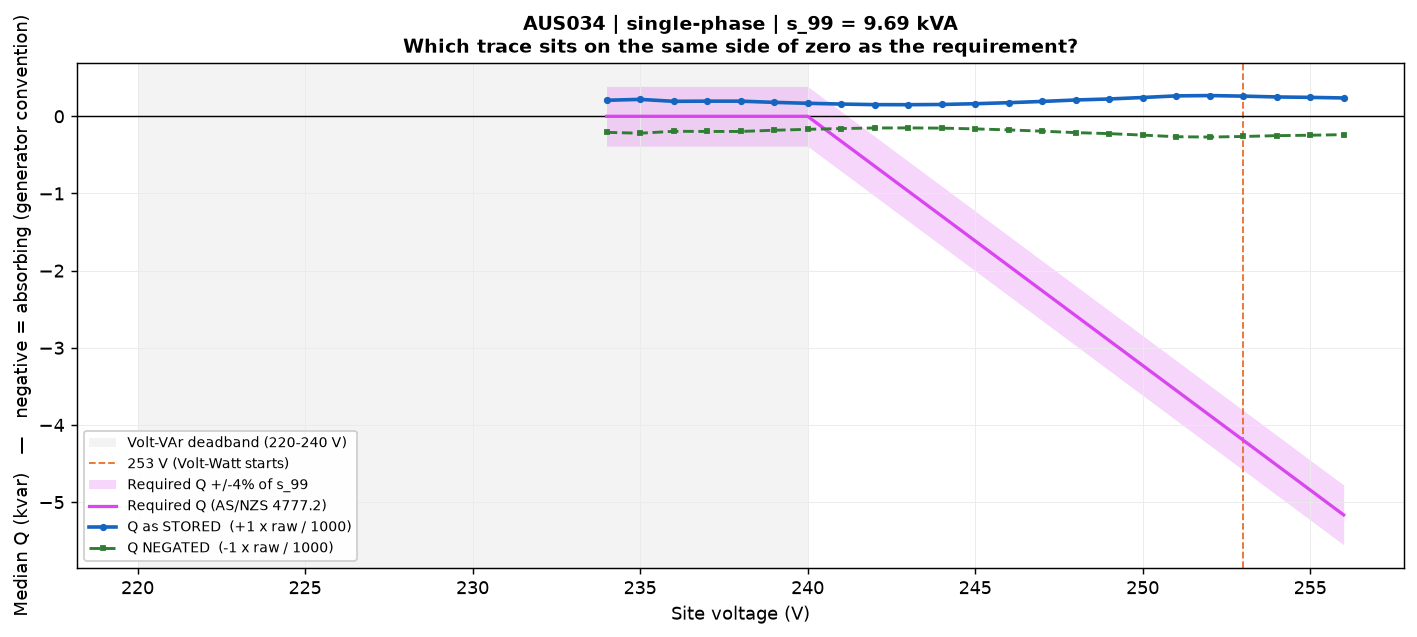

,v_bin,n_intervals,Q_stored_kvar,Q_flipped_kvar,Q_raw_var,P_kW,s_99
0,234.0,25,0.2080,-0.2080,-208.000000,0.649,9.685818
1,235.0,53,0.2193,-0.2193,-219.300003,0.594,9.685818
2,236.0,118,0.1943,-0.1943,-194.300003,0.660,9.685818
3,237.0,346,0.1964,-0.1964,-196.399994,0.768,9.685818
4,238.0,659,0.1964,-0.1964,-196.399994,0.772,9.685818
5,239.0,966,0.1806,-0.1806,-180.600006,0.928,9.685818
6,240.0,1333,0.1687,-0.1687,-168.699997,1.087,9.685818
7,241.0,2026,0.1588,-0.1588,-158.800003,1.122,9.685818
8,242.0,3014,0.1513,-0.1513,-151.300003,0.979,9.685818
9,243.0,4130,0.1504,-0.1504,-150.399994,1.165,9.685818


In [244]:
curve = ex.site_voltvar_curve(con, SITE)
display(ex.plot_site_voltvar_curve(curve, SITE, ex.site_profile(con, SITE)))
display(curve.head(12));

## 3. The daily operational plot

Five panels — voltage, active power, Volt-Watt non-conformance, reactive power, Volt-VAr
non-conformance — ported from `plot_operational_ausgrid`.

`site_days_available()` ranks days by how much time they spend above 240 V, because a day
that never enters the Volt-VAr band shows a flat reactive trace and settles nothing.

Both orientations are plotted below. **Compare the fourth panel**: the blue measured
trace against the magenta required band.

In [245]:
days = ex.site_days_available(con, SITE)
display(days.head(8))
days

,day_aest,n_intervals,n_above_240,n_above_253,max_V,max_P_kW,max_abs_Q_kvar
0,2025-01-03,175,175,14,254.699997,9.49,0.684
1,2025-01-01,175,175,18,254.800003,9.99,0.567
2,2025-01-10,174,174,13,255.000000,9.39,0.602
3,2025-12-09,174,174,12,254.800003,9.96,0.395
4,2025-01-04,174,174,65,254.899994,8.88,0.264
5,2025-01-02,173,173,0,252.399994,7.01,0.530
6,2025-12-05,173,173,28,254.600006,9.47,0.368
7,2025-01-05,173,173,33,254.300003,9.60,0.318


,day_aest,n_intervals,n_above_240,n_above_253,max_V,max_P_kW,max_abs_Q_kvar
0,2025-01-03,175,175,14,254.699997,9.49,0.684
1,2025-01-01,175,175,18,254.800003,9.99,0.567
2,2025-01-10,174,174,13,255.000000,9.39,0.602
3,2025-12-09,174,174,12,254.800003,9.96,0.395
4,2025-01-04,174,174,65,254.899994,8.88,0.264
...,...,...,...,...,...,...,...
360,2025-06-04,124,53,0,245.899994,5.94,0.373
361,2025-07-30,123,45,0,248.699997,3.16,0.486
362,2025-05-18,127,41,0,248.699997,3.35,0.262
363,2025-07-08,124,34,0,246.399994,3.58,0.393


In [261]:
ZOOM_DATE = str(days.day_aest.iloc[2])[:10]
# ZOOM_DATE = "2025-04-16"     # override with any date from days.day_aest
ZOOM_DATE = "2025-01-12"

df_day = ex.site_day(con, SITE, ZOOM_DATE)
assert len(df_day) > 0, f"No rows for {ZOOM_DATE}"
print(f"{len(df_day)} intervals | raw values joined: {df_day.Q_raw_var.notna().sum()}")
display(df_day[["ts_aest", "V", "P_kW", "Q_raw_var", "Q_raw_kvar", "Q_stored_kvar"]].iloc[::24])

164 intervals | raw values joined: 164


,ts_aest,V,P_kW,Q_raw_var,Q_raw_kvar,Q_stored_kvar
0,2025-01-12 05:05:45,244.230331,0.000000,0.000000,0.000000,0.000000
24,2025-01-12 07:05:45,245.306244,3.588672,168.002975,0.168003,0.168003
48,2025-01-12 09:05:45,253.037842,8.529457,232.637054,0.232637,0.232637
72,2025-01-12 11:05:45,253.378494,8.531279,318.973358,0.318973,0.318973
96,2025-01-12 13:05:45,253.313263,8.570940,276.362091,0.276362,0.276362
120,2025-01-12 15:05:45,253.810181,7.935434,275.855042,0.275855,0.275855
144,2025-01-12 17:05:45,245.086716,0.953298,133.905518,0.133906,0.133906


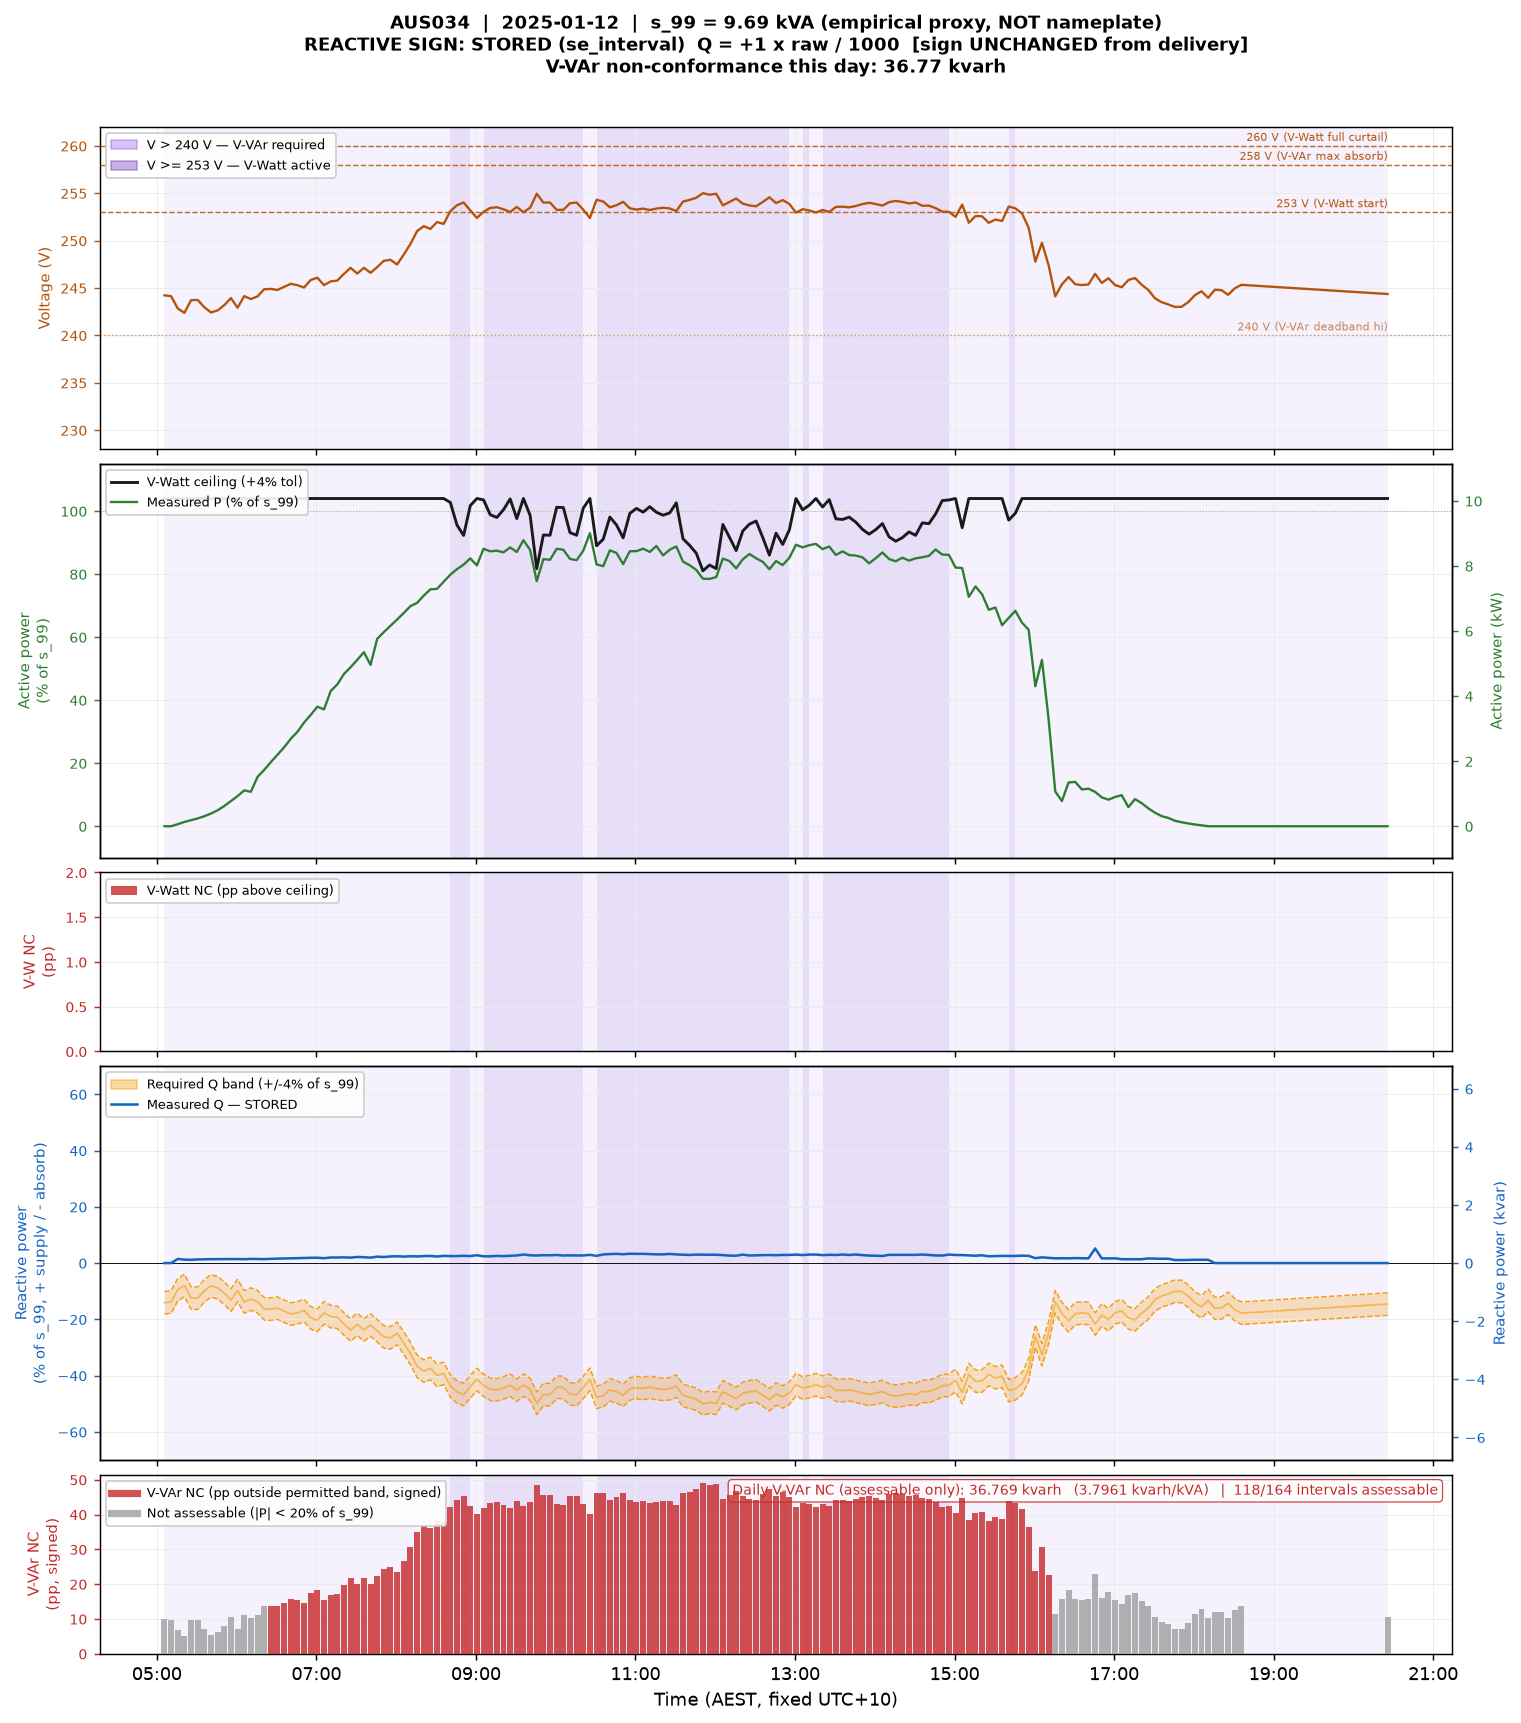

In [262]:
S = float(df_day.s_99.iloc[0])
display(ex.plot_operational(df_day, SITE, S, ZOOM_DATE, orientation="stored"))

### 3b. Volt-Watt — why the operational plot cannot answer this

`plot_operational` is the right tool for Volt-VAr and the wrong one for Volt-Watt, and
that is not a defect in the figure.

**Volt-VAr** asks *is Q on the curve?* — answerable from Q and V alone, both measured.
**Volt-Watt** asks *is P below the ceiling?* — and a site sitting far below the ceiling
looks identical whether it curtailed correctly or simply had no sun. You cannot tell
those apart from measured data. It needs a third trace: what the site **could** have
produced.

That is why a site can be scored "Volt-Watt conformant" and still look like nothing is
happening. Most of the time nothing *is* — 71% of this fleet never reaches 253 V at all,
and among those that do, most exposed intervals sit well under the ceiling because the
sun was not there.

The plot below adds the ceiling and the counterfactual, and shades the two outcomes:

| shading | meaning |
|---|---|
| **orange** | power was available *and* the site held below the ceiling — Volt-Watt **working**, observed |
| **red** | measured P above the ceiling — **non-conformant** |

Neither shading, with P well under the ceiling, means the inverter was never asked to
respond. Conformant, but demonstrating nothing.

`uncurtailed_P` needs `se_uncurtailedpv` from notebook 04 §5. Without it the plot still
shows the ceiling and any breaches, but curtailment cannot be assessed — and it says so
in the title rather than leaving you to infer it.

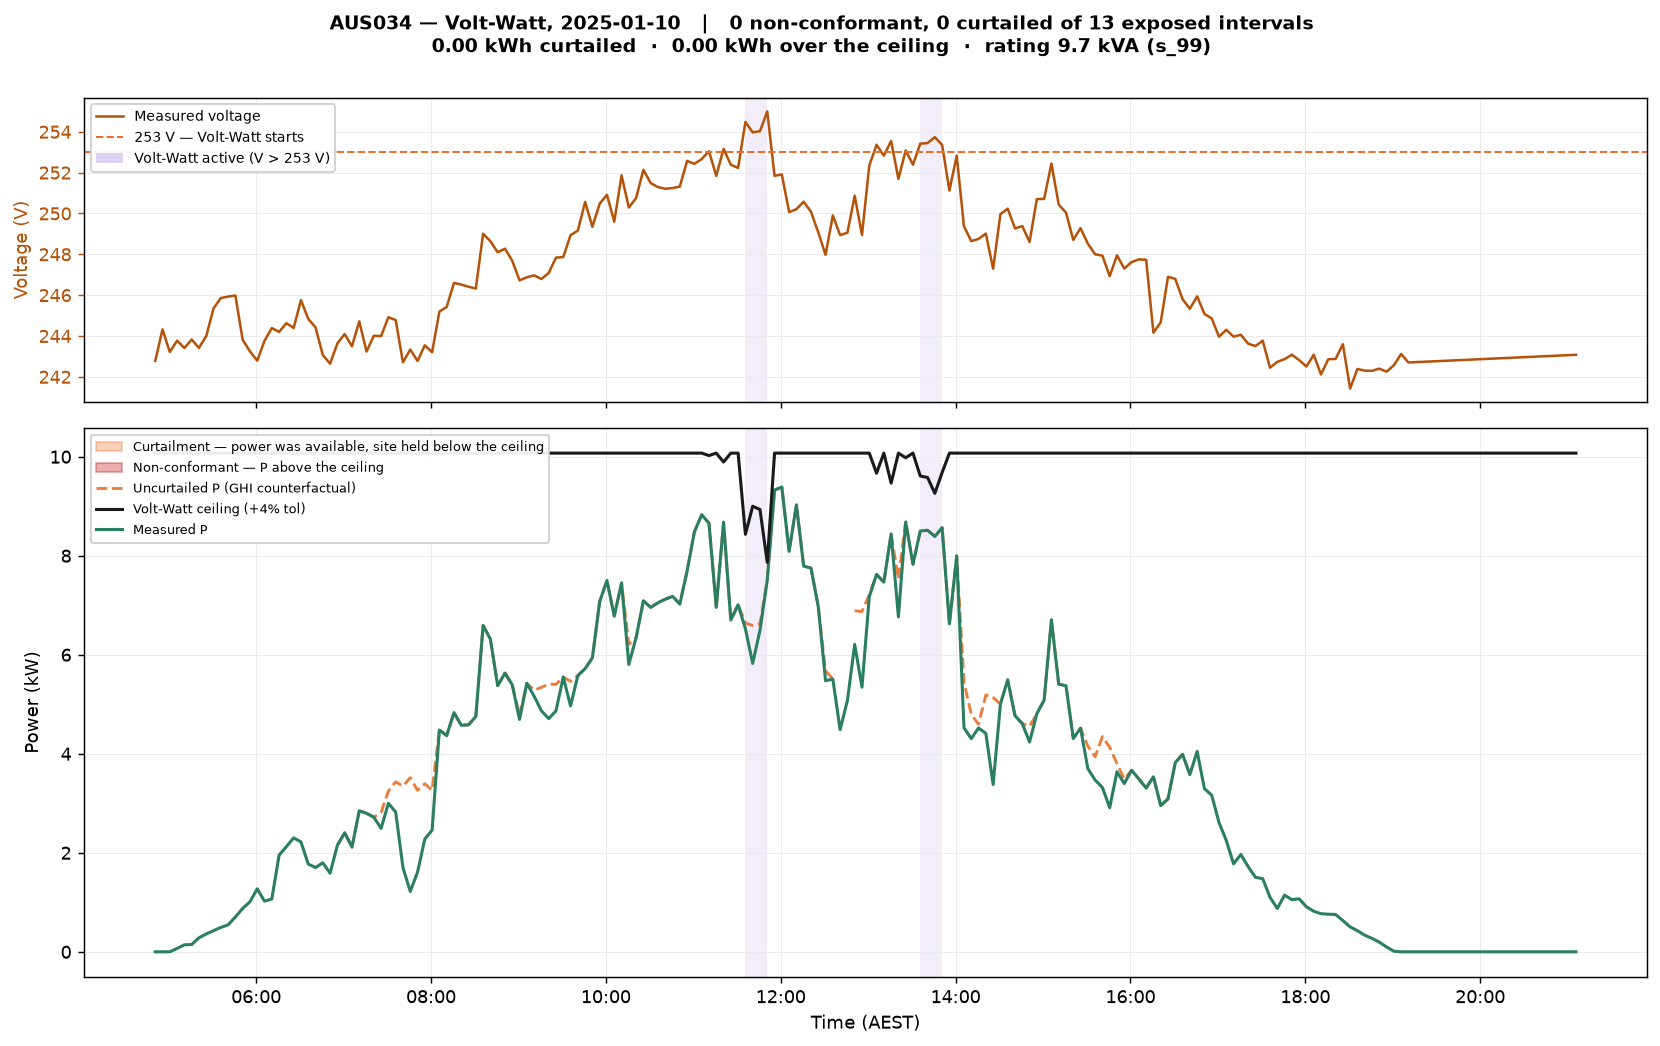

13 of 174 intervals exposed (V > 253 V)


,ts_aest,V,P_kW,P_ceiling_kW,uncurtailed_P,nonconformant,curtailed
76,2025-01-10 11:10:44,253.044464,8.658557,10.024031,8.658557,False,False
78,2025-01-10 11:20:44,253.162186,8.676622,9.893719,8.676622,False,False
81,2025-01-10 11:35:44,254.481628,6.525405,8.433161,6.642207,False,False
82,2025-01-10 11:40:44,253.969742,5.825261,8.999794,6.590802,False,False
83,2025-01-10 11:45:44,254.028732,6.494317,8.934495,6.625095,False,False
84,2025-01-10 11:50:44,254.994629,7.507658,7.865295,7.507658,False,False
99,2025-01-10 13:05:44,253.366516,7.622523,9.667536,7.622523,False,False
101,2025-01-10 13:15:44,253.548050,8.442111,9.466587,8.442111,False,False
103,2025-01-10 13:25:44,253.084473,8.684000,9.979744,8.684000,False,False
105,2025-01-10 13:35:44,253.417496,8.501396,9.611104,8.501396,False,False


In [248]:
vw_day = ex.site_voltwatt_day(con, SITE, ZOOM_DATE, config)
display(ex.plot_voltwatt_day(vw_day, SITE, ZOOM_DATE, config))

# The intervals the verdict actually rests on
exposed = vw_day[vw_day.exposed.fillna(False)]
print(f"{len(exposed):,} of {len(vw_day):,} intervals exposed (V > 253 V)")
if len(exposed):
    display(exposed[["ts_aest", "V", "P_kW", "P_ceiling_kW", "uncurtailed_P",
                     "nonconformant", "curtailed"]].head(12))

#### Pick a day that actually tests Volt-Watt

A day with no exposure tells you nothing about the response. This ranks the site's days
by how much high voltage they saw, so the plot above can be pointed at a day where the
question was genuinely asked.

,day_aest,n_intervals,n_above_253,v_max,p_max_kW
0,2025-01-12,164,75,255.000000,9.01
1,2025-01-20,172,65,256.000000,8.78
2,2025-01-04,174,65,254.899994,8.88
3,2025-01-25,169,63,256.200012,9.38
4,2025-02-17,163,62,254.899994,9.52
5,2025-11-19,169,56,255.300003,9.28
6,2025-02-19,160,54,256.399994,9.38
7,2025-12-02,172,52,256.200012,10.00
8,2025-12-03,173,50,256.000000,9.30
9,2025-02-16,163,49,256.500000,9.51


Most-exposed day: 2025-01-12


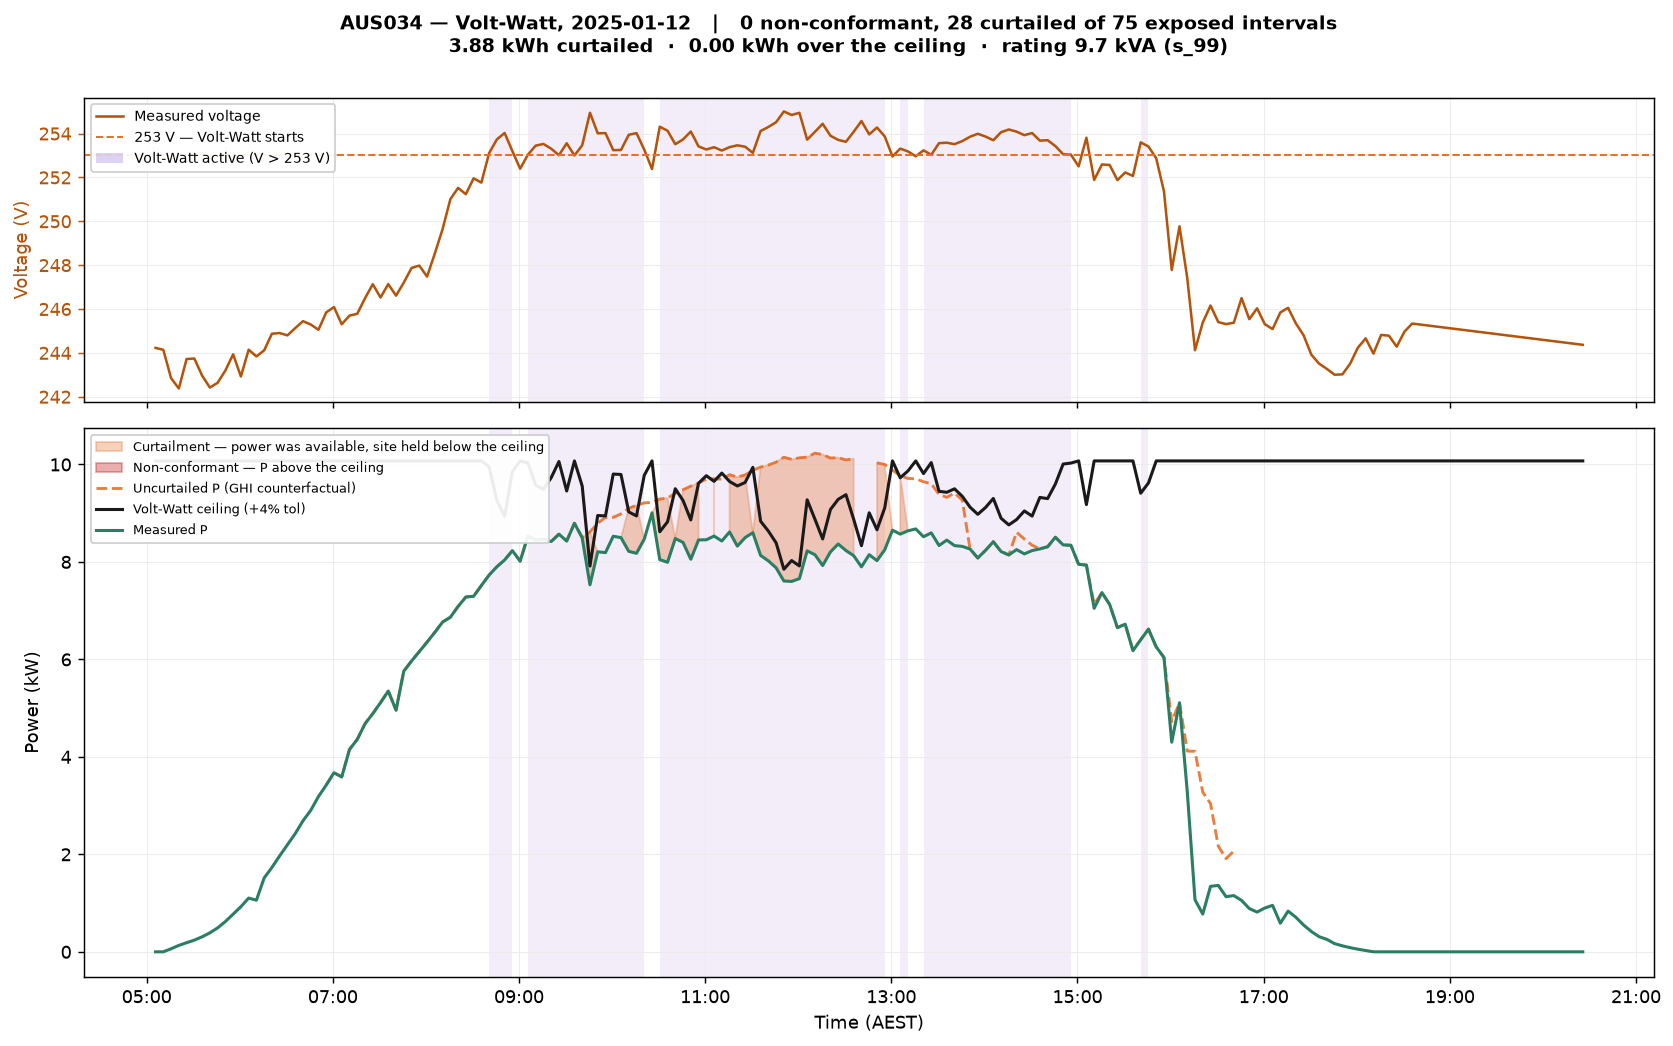

In [249]:
vw_days = con.execute(f"""
    SELECT CAST(ts_aest AS DATE)                            AS day_aest,
           count(*)                                          AS n_intervals,
           count(*) FILTER (WHERE V_mean > {C.as4777()['VW']['V1']}) AS n_above_253,
           round(max(V_mean), 1)                             AS v_max,
           round(max(P_kW), 2)                               AS p_max_kW
    FROM se_interval
    WHERE site_alias = '{SITE}'
    GROUP BY 1
    HAVING n_above_253 > 0
    ORDER BY n_above_253 DESC
    LIMIT 15
""").df()
display(vw_days)

if len(vw_days):
    VW_DATE = str(vw_days.day_aest.iloc[0])[:10]
    print(f"Most-exposed day: {VW_DATE}")
    display(ex.plot_voltwatt_day(
        ex.site_voltwatt_day(con, SITE, VW_DATE, config), SITE, VW_DATE, config))
else:
    print(f"{SITE} never exceeded 253 V — Volt-Watt was never tested for this site.")

#### Per-timestamp classification — the Volt-Watt analogue of the Volt-VAr table

Five categories, not two, because **"P below the ceiling" covers three genuinely
different situations** and collapsing them is what makes a "conformant" verdict hard to
read:

| category | meaning | evidence value |
|---|---|---|
| `not_exposed` | V ≤ 253 V | no limit applied |
| `nonconformant` | P above the ceiling | **proof it failed** |
| `curtailed` | below ceiling, counterfactual says the sun *was* there | **proof it works** |
| `sun_limited` | below ceiling, counterfactual says the sun was *not* there | nothing tested |
| `no_counterfactual` | below ceiling, no prediction available | unanswerable |

Only two of the five carry evidence. `uncurtailed_P` is on every row, so you can see the
number the classification turned on.

In [250]:
vw_cats = ex.site_voltwatt_categories(con, SITE, VW_DATE, config)
display(ex.voltwatt_day_summary(vw_cats))

# Every exposed interval, with the counterfactual that decided its category
display(vw_cats[vw_cats.category != "not_exposed"].head(30))

vw_cats.to_csv(C.ARTEFACT_DIR / f"voltwatt_intervals_{SITE}_{VW_DATE}.csv", index=False)
print(f"-> {C.ARTEFACT_DIR / f'voltwatt_intervals_{SITE}_{VW_DATE}.csv'}")

,category,n_intervals,pct_of_day,kWh_over_ceiling,kWh_available_not_taken
0,not_exposed,89,54.3,0.0,0.000
1,nonconformant,0,0.0,0.0,0.000
2,curtailed,28,17.1,0.0,3.881
3,sun_limited,45,27.4,0.0,0.000
4,no_counterfactual,2,1.2,0.0,0.000


,ts_aest,V,P_kW,P_ceiling_kW,uncurtailed_P,headroom_kW,category,excess_kW,available_kW,derating_active
43,2025-01-12 08:40:45,253.108536,7.731079,9.953107,7.731079,2.2220,sun_limited,0.0,0.0000,False
44,2025-01-12 08:45:45,253.734161,7.901749,9.260570,7.901749,1.3588,sun_limited,0.0,0.0000,False
45,2025-01-12 08:50:45,254.026123,8.040709,8.937383,8.040709,0.8967,sun_limited,0.0,0.0000,False
46,2025-01-12 08:55:45,253.199844,8.232148,9.852033,8.232148,1.6199,sun_limited,0.0,0.0000,False
48,2025-01-12 09:05:45,253.037842,8.529457,10.031362,8.529457,1.5019,sun_limited,0.0,0.0000,True
49,2025-01-12 09:10:45,253.448334,8.449923,9.576967,8.449923,1.1270,sun_limited,0.0,0.0000,True
50,2025-01-12 09:15:45,253.526047,8.468767,9.490943,8.468767,1.0222,sun_limited,0.0,0.0000,True
51,2025-01-12 09:20:45,253.311508,8.418693,9.728427,8.418693,1.3097,sun_limited,0.0,0.0000,True
52,2025-01-12 09:25:45,253.011948,8.569863,10.060025,8.569863,1.4902,sun_limited,0.0,0.0000,True
53,2025-01-12 09:30:45,253.557907,8.429238,9.455675,8.429238,1.0264,sun_limited,0.0,0.0000,True


-> C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\solar_edge\artefacts\voltwatt_intervals_AUS034_2025-01-12.csv


#### Why is the counterfactual patchy?

Because it is produced **per five-minute time-of-day bin**, not per interval. Each bin
gets its own regression, and a bin needs at least 5 surviving training rows to get one at
all. If a site's 11:25 bin never accumulated five usable rows across the whole record,
then *every* 11:25 in the year has no prediction — which is why the dashed line is
speckled rather than simply truncated.

So yes, this is expected behaviour. But it is a **coverage limitation to quantify, not
decoration** — every gap is an interval that falls into the `uncurtailed_P IS NULL`
fallback in notebook 03 §5b, where it gets scored by the basic test instead.

The two cells below say *which* filter is responsible for this particular site. Do not
assume — the binding constraint differs between sites, and on the site I profiled the
biggest cut was **not** the one you would guess.

In [251]:
display(ex.counterfactual_training_attrition(con, SITE))

AUS034: 24,830 of 51,321 intervals (48.4%) are eligible to train on.
  Then 70% go to training, and each 5-minute time-of-day bin needs >= 2 of them
  to get a model at all — bins below that produce no prediction, all year.


,filter,surviving,lost_here,pct_lost_here,pct_of_original
0,all structured intervals,51321,0,0.0,100.0
1,GHI_cs > 0,51320,1,0.0,100.0
2,P_kw_norm_cs > 0.2 (dawn/dusk cut),42043,9277,18.1,81.9
3,GHI > 50,40706,1337,3.2,79.3
4,P_kw_norm > 0.05,38868,1838,4.5,75.7
5,P_kw_norm <= P_kw_norm_cs (quality gate),27804,11064,28.5,54.2
6,V_mean <= 253 (exclude Volt-Watt zone),24830,2974,10.7,48.4


In [252]:
gaps = ex.voltwatt_counterfactual_gaps(con, SITE, VW_DATE, config)
gaps["hour"] = pd.to_datetime(gaps.tod_bin.astype(str), format="%H:%M:%S").dt.hour

by_hour = gaps.groupby("hour").agg(
    bins=("tod_bin", "size"),
    bins_with_model=("model_exists", "sum"),
    mean_V=("mean_V", "mean"),
    exposed_intervals=("n_exposed", "sum"),
).round(1)
by_hour["pct_covered"] = (100 * by_hour.bins_with_model / by_hour.bins).round(0)
display(by_hour)

print(f"{int(gaps.model_exists.sum())} of {len(gaps)} time-of-day bins on this day "
      f"have a model.")
print("Coverage improves with record length — a 3-month store is far patchier than 12.")

,bins,bins_with_model,mean_V,exposed_intervals,pct_covered
hour,,,,,
5,11,0,243.3,0,0.0
6,12,1,244.7,0,8.0
7,12,12,246.6,0,100.0
8,12,12,251.4,4,100.0
9,12,12,253.5,11,100.0
10,12,12,253.6,11,100.0
11,12,12,253.8,12,100.0
12,12,10,254.1,12,83.0
13,12,12,253.4,10,100.0


116 of 164 time-of-day bins on this day have a model.
Coverage improves with record length — a 3-month store is far patchier than 12.


#### Which step lost each missing interval

A row must survive **five** things to get a counterfactual:

| # | step | fails when |
|---|---|---|
| 1 | reach `se_structured` | no BOM irradiance for that (postcode, 5-min slot) |
| 2 | `GHI_cs > 0` | no clear-sky irradiance reference at that time of day |
| 3 | `P_kw_norm_cs > 0` | no clear-sky power reference at that time of day |
| 4 | a model for `(site, tod_bin)` | the bin had too few training rows |
| 5 | site passed the MAPE gate | model can't predict this site at all (≤ 50% median error) |

Steps 4 and 5 are properties of the **site and clock time** — if they're the cause, that
same clock time is missing on *every* day of the record. Step 1 is a property of **that
day** — a gap in the satellite feed. On a single day plot the two look identical and mean
completely different things, so `bin_covered_other_days` separates them:

- `= 0` → **structural**: model or gate. Missing all year.
- `> 0` → **transient**: BOM gap on this day only.

**A telltale for step 1:** BOM is 10-minute data duplicated into 5-minute slots (`t` and
`t+5`), so **one** missing satellite record removes **exactly two adjacent** 5-minute
slots. Two consecutive gaps in the middle of an otherwise covered block is that signature
— not a training-data problem.

In [253]:
missing = ctf.explain_missing_counterfactual(con, SITE, VW_DATE, config)
if len(missing):
    display(missing[["ts_aest", "tod_bin", "in_structured", "GHI_cs",
                     "P_kw_norm_cs", "model_exists", "model_train_points",
                     "bin_covered_other_days", "reason", "verdict"]])

AUS034 on 2025-01-12: 48 interval(s) without a counterfactual

  1. no BOM irradiance for this postcode/slot  x3
  4. no model for this time-of-day bin (too few training rows)  x45


,ts_aest,tod_bin,in_structured,GHI_cs,P_kw_norm_cs,model_exists,model_train_points,bin_covered_other_days,reason,verdict
0,2025-01-12 05:05:45,05:05:00,True,40.0,0.0171,False,<NA>,0,4. no model for this time-of-day bin (too few ...,structural (missing all year)
1,2025-01-12 05:10:45,05:10:00,True,64.2,0.0212,False,<NA>,0,4. no model for this time-of-day bin (too few ...,structural (missing all year)
2,2025-01-12 05:15:45,05:15:00,True,64.2,0.0241,False,<NA>,0,4. no model for this time-of-day bin (too few ...,structural (missing all year)
3,2025-01-12 05:20:45,05:20:00,True,91.0,0.0221,False,<NA>,0,4. no model for this time-of-day bin (too few ...,structural (missing all year)
4,2025-01-12 05:25:45,05:25:00,True,91.0,0.0275,False,<NA>,0,4. no model for this time-of-day bin (too few ...,structural (missing all year)
5,2025-01-12 05:30:45,05:30:00,True,112.9,0.0300,False,<NA>,0,4. no model for this time-of-day bin (too few ...,structural (missing all year)
6,2025-01-12 05:35:45,05:35:00,True,98.5,0.0309,False,<NA>,0,4. no model for this time-of-day bin (too few ...,structural (missing all year)
7,2025-01-12 05:40:45,05:40:00,True,113.2,0.0316,False,<NA>,0,4. no model for this time-of-day bin (too few ...,structural (missing all year)
8,2025-01-12 05:45:45,05:45:00,True,113.2,0.0296,False,<NA>,0,4. no model for this time-of-day bin (too few ...,structural (missing all year)
9,2025-01-12 05:50:45,05:50:00,True,145.1,0.0401,False,<NA>,0,4. no model for this time-of-day bin (too few ...,structural (missing all year)


### 3c. Volt-VAr scatter — *where on the curve* the site fails

The daily plot shows **when** a site misbehaves. This shows **where on the curve**, and
the two failure shapes look completely different:

- a **flat horizontal band near Q = 0** across the whole voltage range → Volt-VAr is
  **disabled**. The inverter never responds at any voltage.
- points that **track the required curve but sit short of it** → responding with the
  **wrong settings**, or a smaller capability than assumed.

Both produce similar non-conformance percentages. Only this view separates them, and they
call for different follow-up — one is a commissioning problem, the other a settings
problem.

Colours come from `site_interval_categories`, which runs the **same D9 SQL that produced
the fleet numbers**, so a point coloured "adverse" here is one of the intervals counted as
adverse in notebook 03. The explorer and the headline cannot drift apart.

Category breakdown for AUS034 (53,737 intervals):
  not_assessable               21,155  ( 39.4%)
  within_band                     453  (  0.8%)
  Q_near_conformant                23  (  0.0%)
  Q_major_surplus                 255  (  0.5%)
  Q_inactive                   19,471  ( 36.2%)
  Q_adverse                    12,380  ( 23.0%)


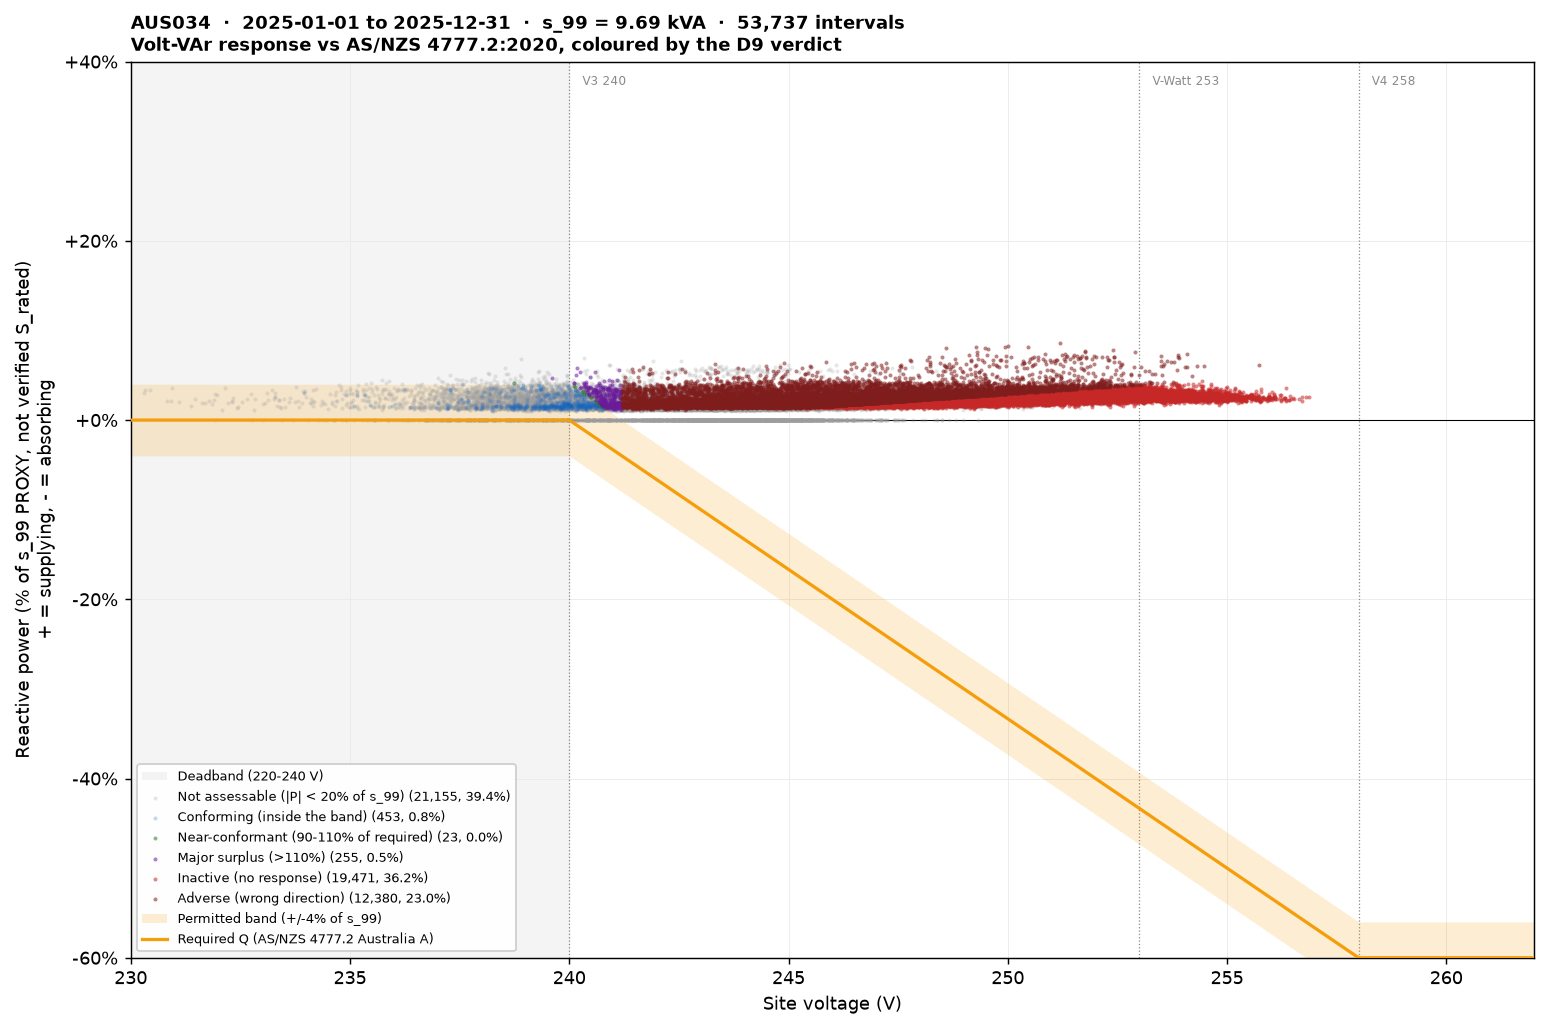

In [254]:
# Whole store for this site; pass a slice for a single month.
cats_all = ex.site_interval_categories(con, SITE, config=config)
profile = ex.site_profile(con, SITE, config)

display(ex.plot_voltvar_scatter(
    cats_all, SITE, float(profile.s_99),
    period_label=f"{cats_all.ts_aest.min():%Y-%m-%d} to {cats_all.ts_aest.max():%Y-%m-%d}",
    config=config))

One month at a time, if a site's behaviour changed part-way through the year — a firmware
update or a re-commissioning shows up as the cloud moving between months.

Category breakdown for AUS034 (5,306 intervals):
  not_assessable                1,995  ( 37.6%)
  within_band                     218  (  4.1%)
  Q_near_conformant                10  (  0.2%)
  Q_major_surplus                  69  (  1.3%)
  Q_inactive                    1,079  ( 20.3%)
  Q_adverse                     1,935  ( 36.5%)


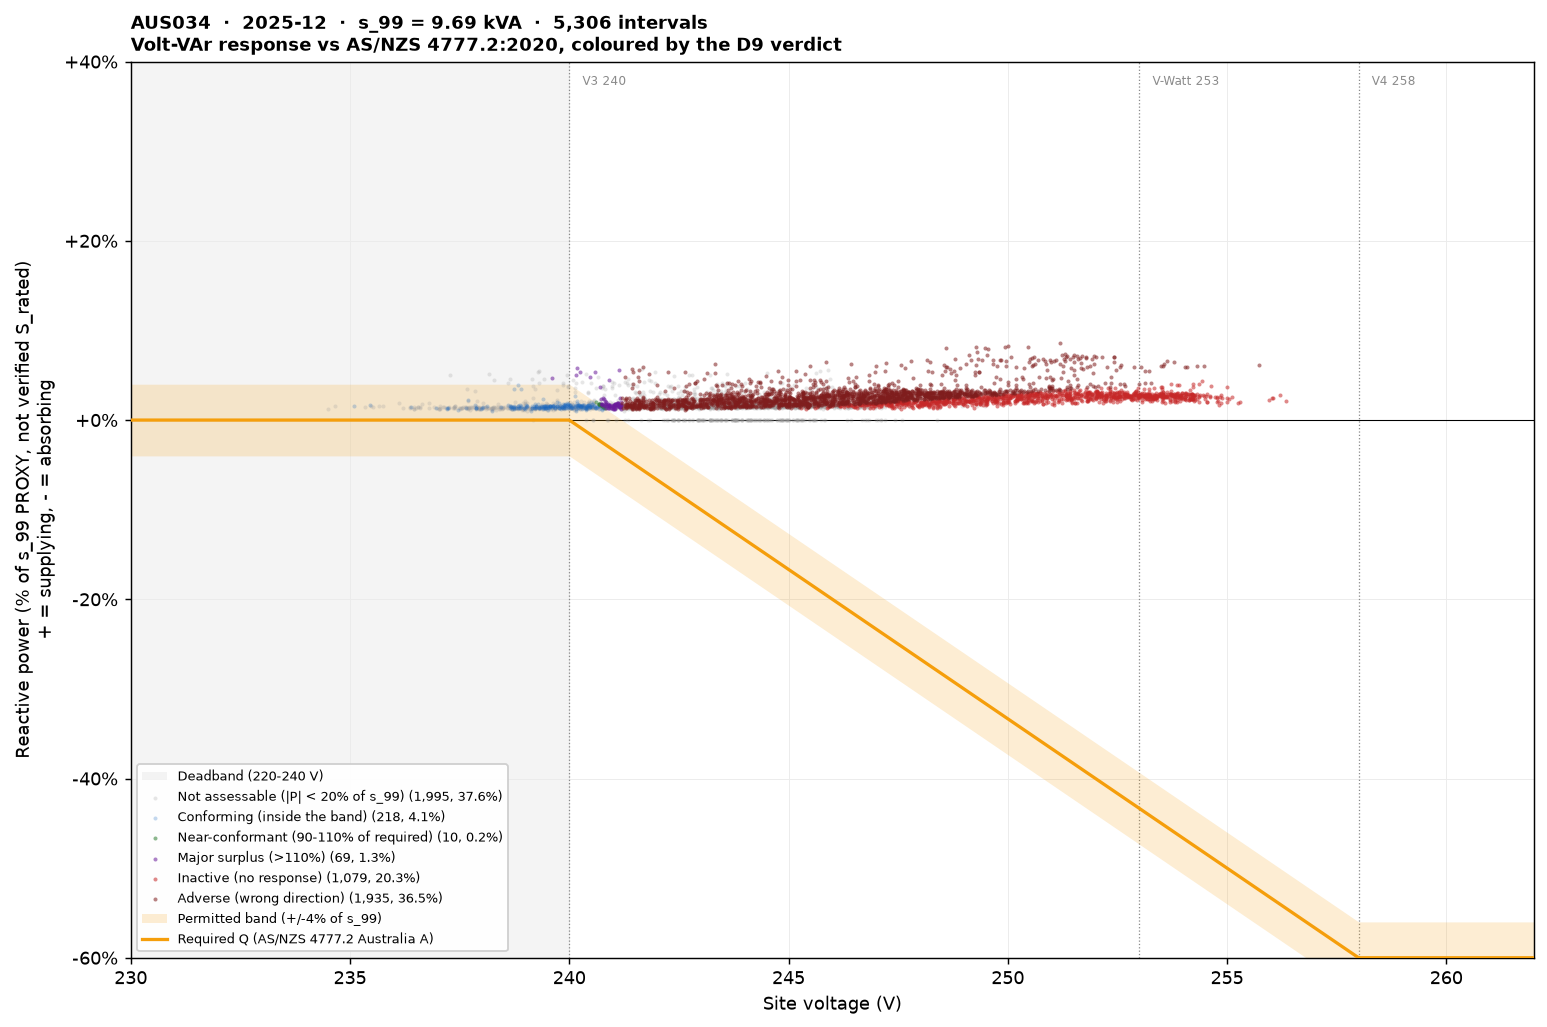

In [255]:
MONTH = str(cats_all.ts_aest.dt.to_period("M").iloc[-1])   # e.g. "2025-12"
month_cats = cats_all[cats_all.ts_aest.dt.to_period("M").astype(str) == MONTH]

if len(month_cats):
    display(ex.plot_voltvar_scatter(month_cats, SITE, float(profile.s_99),
                                    period_label=MONTH, config=config))
else:
    print(f"No intervals for {SITE} in {MONTH}.")

In [256]:
cats = ex.site_interval_categories(con, SITE, ZOOM_DATE)
display(cats.category.value_counts().rename("intervals").to_frame())
display(cats[["ts_aest", "V", "P_kW", "Q_kvar", "Q_min_permitted", "Q_max_permitted",
              "Q_impact", "category", "dist_to_band_kvar"]])

,intervals
category,
Q_inactive,86
not_assessable,49
Q_adverse,39


,ts_aest,V,P_kW,Q_kvar,Q_min_permitted,Q_max_permitted,Q_impact,category,dist_to_band_kvar
0,2025-01-10 04:50:44,242.779999,0.000,0.0000,-1.2847,0.3874,NaN,not_assessable,0.0
1,2025-01-10 04:55:44,244.320007,0.000,0.0000,-1.7825,0.3874,NaN,not_assessable,0.0
2,2025-01-10 05:00:44,243.220001,0.000,0.0000,-1.4262,0.3874,NaN,not_assessable,0.0
3,2025-01-10 05:05:44,243.770004,0.068,0.1250,-1.6050,0.3874,NaN,not_assessable,0.0
4,2025-01-10 05:10:44,243.410004,0.142,0.1195,-1.4881,0.3874,NaN,not_assessable,0.0
...,...,...,...,...,...,...,...,...,...
169,2025-01-10 18:55:44,242.250000,0.098,0.1133,-1.1147,0.3874,NaN,not_assessable,0.0
170,2025-01-10 19:00:44,242.559998,0.012,0.1131,-1.2155,0.3874,NaN,not_assessable,0.0
171,2025-01-10 19:05:44,243.119995,0.000,0.0000,-1.3944,0.3874,NaN,not_assessable,0.0
172,2025-01-10 19:10:44,242.699997,0.000,0.0000,-1.2599,0.3874,NaN,not_assessable,0.0


## 4. Fleet-wide: which orientation fits the required curve?

Not a sample — **every site in the fleet**.

For each site, across the Volt-VAr ramp only (241–253 V, where the requirement is
non-zero and Volt-Watt has not yet engaged), compute the median absolute deviation of
measured Q from the required curve in both orientations, and compare against the ±4%
tolerance band.

Three outcomes:

- **`raw fits`** — as-delivered is within tolerance, flipped is not. The flip broke it.
- **`stored fits`** — the reverse. The flip was right for this site.
- **`neither fits`** — the site is not following the curve either way, so it carries no
  information about the convention and should be excluded from the argument.

In [257]:
'''
fit = sign.fleet_orientation_fit(con)
print(f"{len(fit):,} of 1,602 sites had enough data in the ramp\n")
display(pd.crosstab(fit.cohort, fit.verdict, margins=True))

informative = fit[fit.verdict.str.contains(r"fits \(within")]
print(f"\nInformative sites (fit exactly one orientation): {len(informative):,}")
display(pd.crosstab(informative.cohort, informative.verdict))

fit.to_csv(C.ARTEFACT_DIR / "fleet_orientation_fit.csv", index=False)
print(f"\nFull per-site table -> {C.ARTEFACT_DIR / 'fleet_orientation_fit.csv'}")
'''

'\nfit = sign.fleet_orientation_fit(con)\nprint(f"{len(fit):,} of 1,602 sites had enough data in the ramp\n")\ndisplay(pd.crosstab(fit.cohort, fit.verdict, margins=True))\n\ninformative = fit[fit.verdict.str.contains(r"fits \\(within")]\nprint(f"\nInformative sites (fit exactly one orientation): {len(informative):,}")\ndisplay(pd.crosstab(informative.cohort, informative.verdict))\n\nfit.to_csv(C.ARTEFACT_DIR / "fleet_orientation_fit.csv", index=False)\nprint(f"\nFull per-site table -> {C.ARTEFACT_DIR / \'fleet_orientation_fit.csv\'}")\n'

## 5. Look at any site

Change `SITE` and re-run. Useful starting points from the fleet table above:

```python
fit[fit.verdict == "raw fits (within tol)"].head(20)      # flip broke these
fit[fit.verdict == "stored fits (within tol)"].head(20)   # flip was right for these
fit.nsmallest(20, "mad_raw_kvar")                          # cleanest curve-followers
```

site_alias                               AUS034
state                           New South Wales
postcode                                   2290
n_phases                                      1
is_three_phase                            False
n_intervals                               53737
n_days_observed                             365
has_night_generation_anomaly              False
s_99                                       9.69
p_99                                       9.68
pct_derating                             34.725
med_Q_stored_above_250                   0.2597
med_Q_stored_deadband                    0.1914
Name: 0, dtype: object

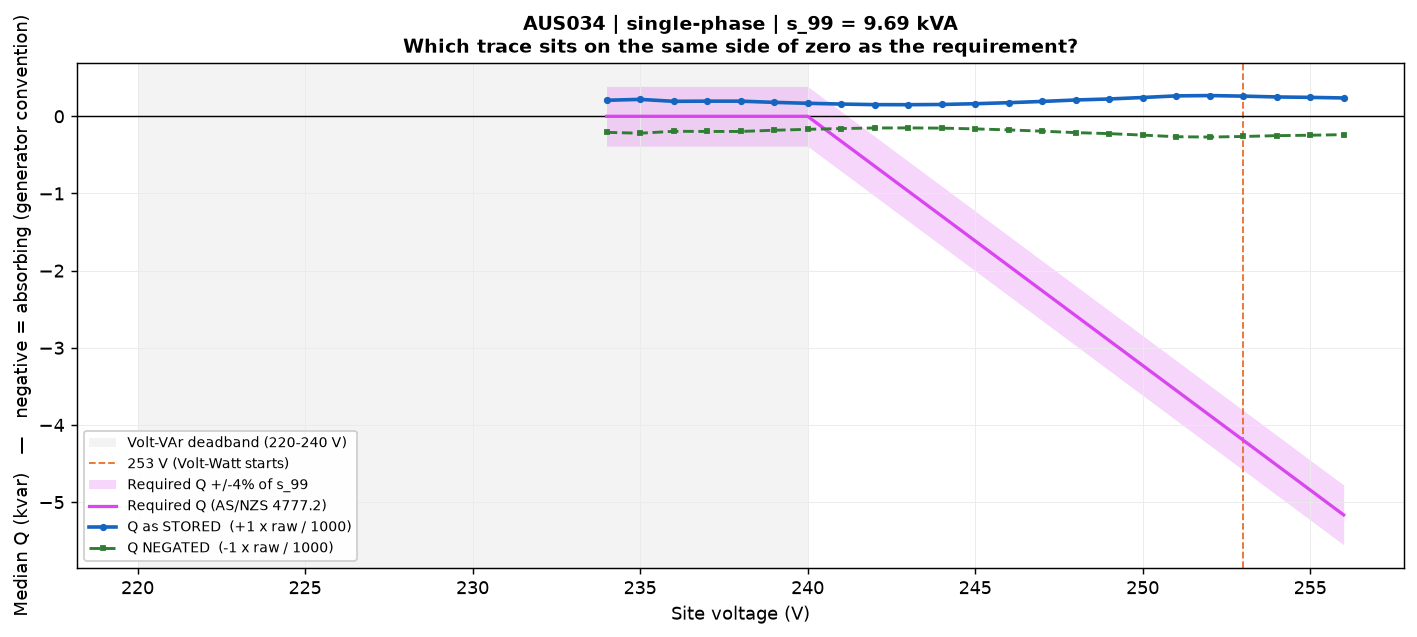

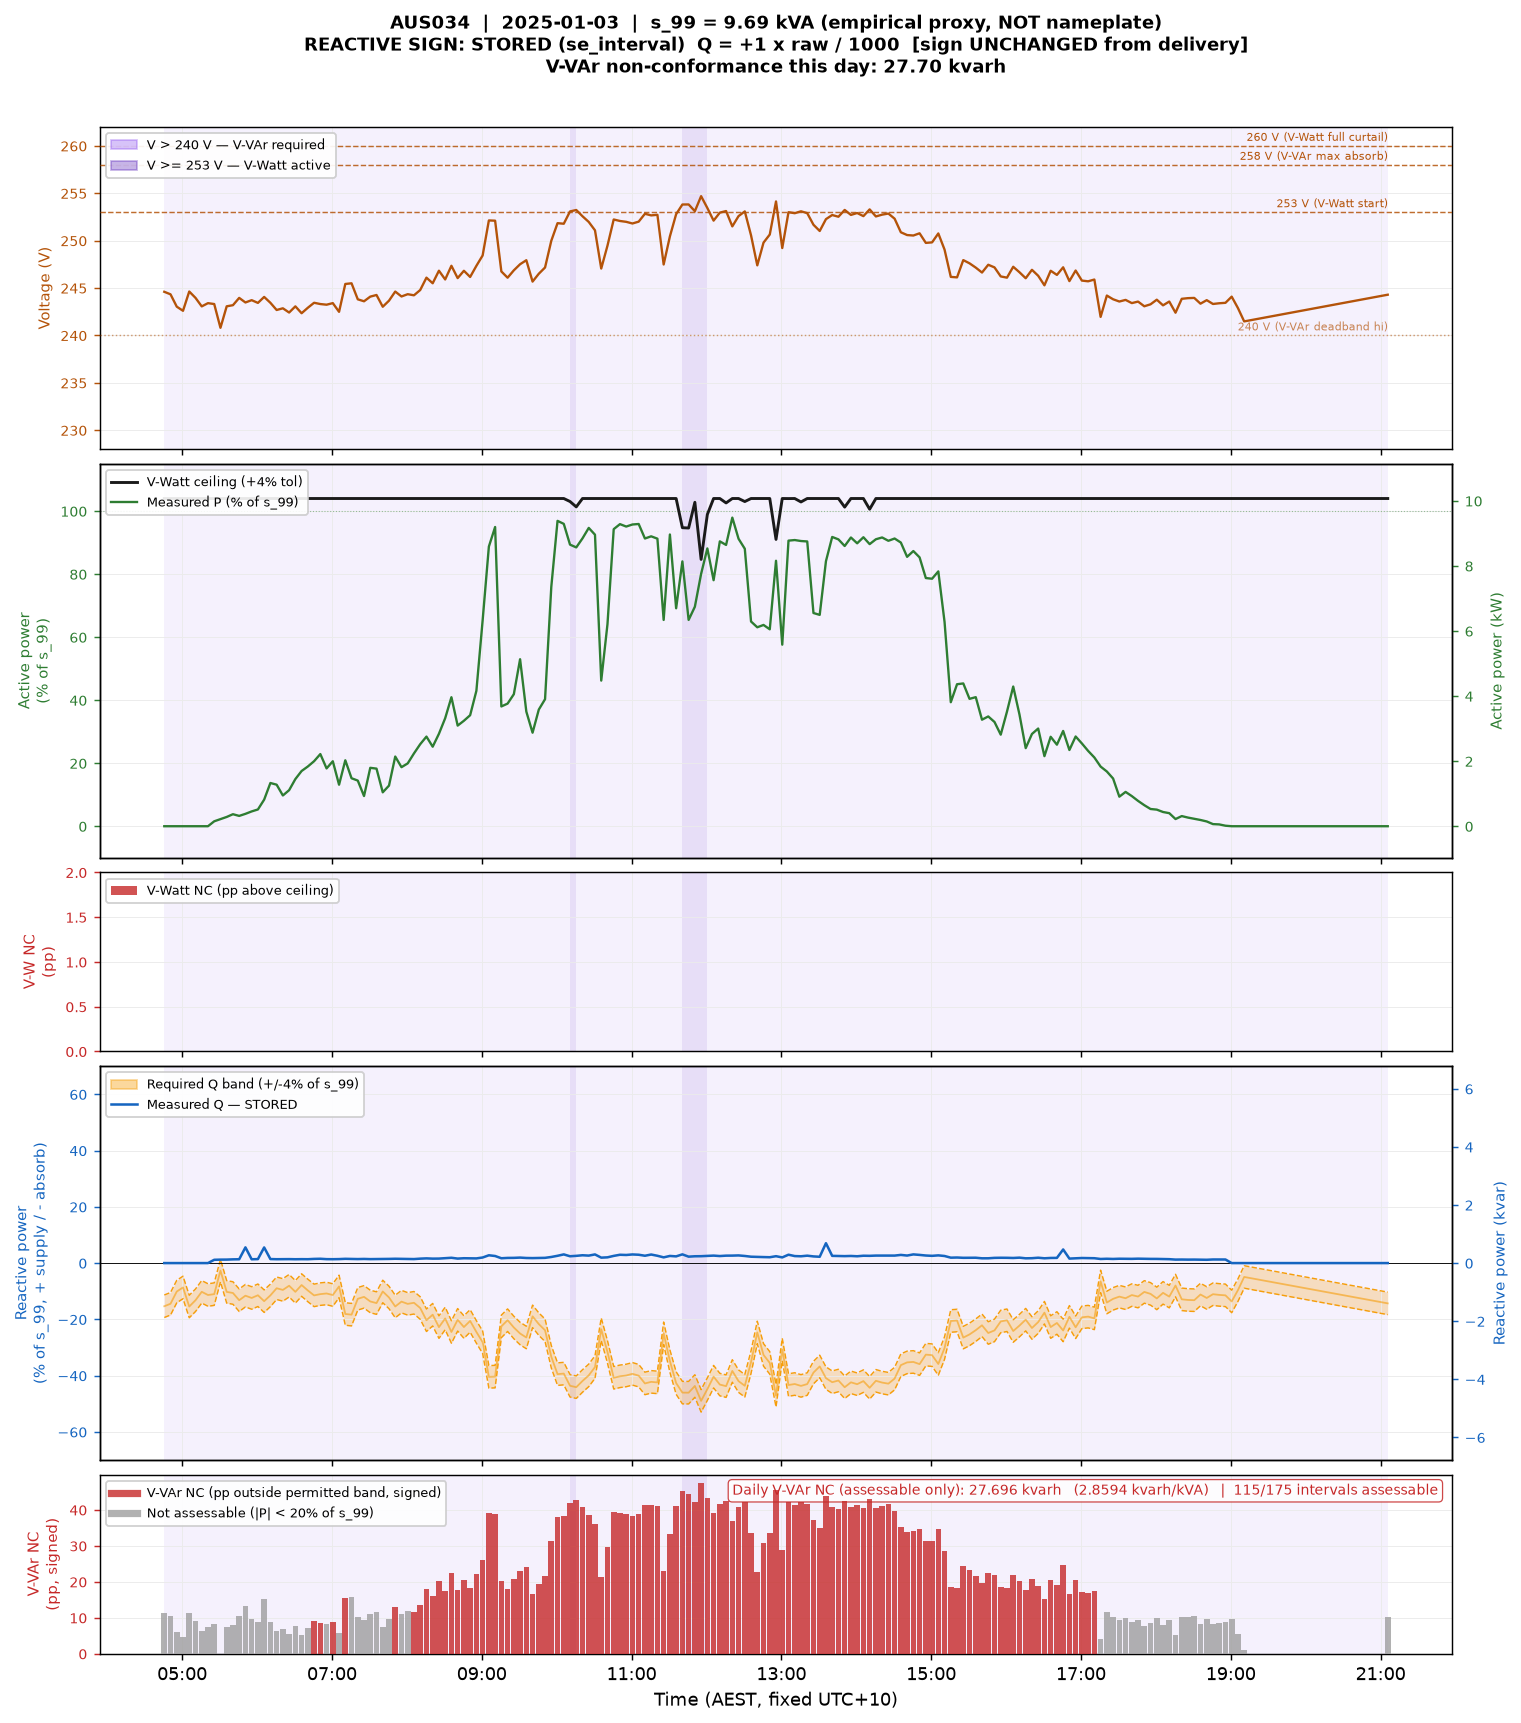

In [258]:
def explore(site, day=None, orientation="raw"):
    """Profile + curve + daily plot for one site. Returns the day frame."""
    display(ex.site_profile(con, site))
    display(ex.plot_site_voltvar_curve(ex.site_voltvar_curve(con, site), site,
                                       ex.site_profile(con, site)))
    avail = ex.site_days_available(con, site)
    day = day or str(avail.day_aest.iloc[0])[:10]
    frame = ex.site_day(con, site, day)
    display(ex.plot_operational(frame, site, float(frame.s_99.iloc[0]), day,
                                orientation=orientation))
    return frame

# The fleet-wide orientation fit in the cell above is commented out (it is a
# whole-fleet scan). Pick a site directly rather than indexing into `fit`, which
# that cell would have defined — otherwise this raises NameError on a clean run.
_ = explore(SITE, orientation="stored")

# With the fit cell uncommented, this selects a site that fits the stored sign:
#     _ = explore(fit[fit.verdict == "stored fits (within tol)"].site_alias.iloc[0],
#                 orientation="stored")

### Per-timestamp categorisation

The same D9 interval scoring, restricted to one site, so the table and the plot are
guaranteed to describe the same thing.

| category | meaning |
|---|---|
| `not_assessable` | \|P\| < 20% of `s_99` — the standard sets no requirement |
| `within_band` | assessable and inside the permitted band — **this is conformance** |
| `Q_adverse` … `Q_major_surplus` | assessable and *outside* the band, split by `Q_impact` |

The five `Q_*` buckets only fire when Q is outside the band, so `within_band` and
`not_assessable` are what account for everything else. A day where the reactive trace
sits inside the amber band all afternoon should be almost entirely those two.

In [259]:
cats = ex.site_interval_categories(con, SITE, ZOOM_DATE)
display(cats.category.value_counts().rename("intervals").to_frame())
display(cats[["ts_aest", "V", "P_kW", "Q_kvar", "Q_min_permitted", "Q_max_permitted",
              "Q_impact", "category", "dist_to_band_kvar"]])

,intervals
category,
Q_inactive,86
not_assessable,49
Q_adverse,39


,ts_aest,V,P_kW,Q_kvar,Q_min_permitted,Q_max_permitted,Q_impact,category,dist_to_band_kvar
0,2025-01-10 04:50:44,242.779999,0.000,0.0000,-1.2847,0.3874,NaN,not_assessable,0.0
1,2025-01-10 04:55:44,244.320007,0.000,0.0000,-1.7825,0.3874,NaN,not_assessable,0.0
2,2025-01-10 05:00:44,243.220001,0.000,0.0000,-1.4262,0.3874,NaN,not_assessable,0.0
3,2025-01-10 05:05:44,243.770004,0.068,0.1250,-1.6050,0.3874,NaN,not_assessable,0.0
4,2025-01-10 05:10:44,243.410004,0.142,0.1195,-1.4881,0.3874,NaN,not_assessable,0.0
...,...,...,...,...,...,...,...,...,...
169,2025-01-10 18:55:44,242.250000,0.098,0.1133,-1.1147,0.3874,NaN,not_assessable,0.0
170,2025-01-10 19:00:44,242.559998,0.012,0.1131,-1.2155,0.3874,NaN,not_assessable,0.0
171,2025-01-10 19:05:44,243.119995,0.000,0.0000,-1.3944,0.3874,NaN,not_assessable,0.0
172,2025-01-10 19:10:44,242.699997,0.000,0.0000,-1.2599,0.3874,NaN,not_assessable,0.0


## 4. The whole year in one figure

A single day proves nothing about an annual rate. This shows every day of the site's
year: **dates across, categories down, colour = % of that day's intervals.**

**Why it is fast.** The aggregation to (day × category) happens in DuckDB, so this
returns at most 365 × 7 = 2,555 cells rather than ~100,000 intervals. It renders in
well under a second. Do *not* fetch the intervals and pivot them client-side.

**How to read it.** A site that is genuinely fine shows a solid `within_band` row with
everything below it empty. Non-conformance appearing as a **vertical stripe** is
episodic — a handful of bad days. As a **horizontal band** it is persistent behaviour.
An annual percentage cannot tell those apart, which is exactly why this is worth
plotting before trusting a site-level verdict.

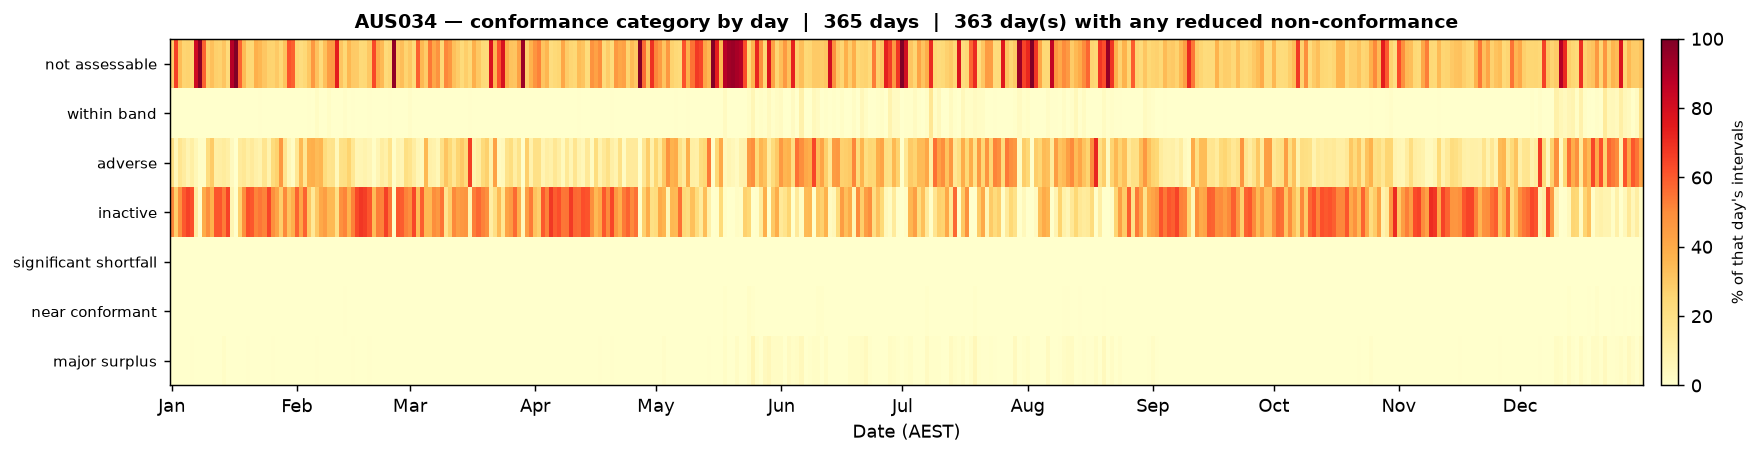

Days with ANY reduced non-conformance: 363 of 365
Worst days:


category,reduced_nonconf_pct,within_band,not_assessable
day_aest,,,
2025-10-31,78.7,0.0,21.3
2025-02-02,77.7,0.0,22.3
2025-04-05,77.6,0.0,22.4
2025-10-10,76.9,0.0,23.1
2025-09-30,76.8,0.0,23.2


In [260]:
calendar = ex.site_category_calendar(con, SITE)
display(ex.plot_category_heatmap(calendar, SITE))

reduced = calendar[["Q_adverse", "Q_inactive", "Q_significant_shortfall"]].sum(axis=1)
print(f"Days with ANY reduced non-conformance: {int((reduced > 0).sum())} of {len(calendar)}")
print(f"Worst days:")
display(calendar.assign(reduced_nonconf_pct=reduced.round(2))
        .nlargest(5, "reduced_nonconf_pct")[["reduced_nonconf_pct", "within_band",
                                             "not_assessable"]].round(1))

## What this establishes

The reactive sign is **inconsistent across the fleet**, and it does not split by phase
count. Within single-phase alone the informative sites divide almost evenly between the
two orientations.

That means **no global constant is correct** — neither the flip currently applied nor
leaving the raw value alone. `se_config.REACTIVE_POWER_SIGN` cannot express this.

It also cannot be fixed by inference. Deriving each site's orientation from whether it
absorbs above 240 V assumes the very behaviour a conformance study is measuring, and
would produce a 100% direction-conformance result by construction.

So until SolarEdge confirms the convention, or a site with known ground truth is
available:

- **magnitude conformance is assessable** — how much reactive power a site delivers
  relative to the requirement is orientation-independent;
- **direction conformance is not** — `Q_adverse` cannot be distinguished from a
  reporting-polarity difference.

The D9 Volt-VAr category results should be read with that restriction, for **both**
cohorts, not just three-phase.